# 02 — SA1 report

**What this notebook does.** Builds the SA1-level reporting table — one row per NT
Statistical Area Level 1 — carrying the 2021 Census population, median household income, an
overcrowding proxy, area, remoteness class, and a roll-up of the BushTel villages inside
each SA1. **The SA1 is the unit for population and equity numbers** (PROJECT_CONTEXT §2);
distances and per-village tiers happen elsewhere.

**What it reads:**

| dataframe | file | what it is |
|---|---|---|
| `sa1_polygons_gdf` | `data/external/abs_boundaries/SA1_2021_AUST_GDA2020_SHP/…shp` | NT SA1 polygons + SA2/3/4 names, EPSG:7844 |
| `ra_workbook_df` | `data/external/abs_boundaries/RA_2021_AUST.xlsx` | SA1 → Remoteness Area + Albers area — the 649-row spine |
| `census_g01_sa1_df` | `…/SA1/NT/2021Census_G01_NT_SA1.csv` | `Tot_P_P` = the only real population |
| `census_g02_sa1_df` | `…/SA1/NT/2021Census_G02_NT_SA1.csv` | median household income, average household size |
| `villages_df` | `data/new_processed/villages.csv` | output of nb 01 — for the village roll-up |

(nb 02 is the one pipeline notebook that reads a `new_processed/` file as well as raw —
the village roll-up needs nb 01's output. Everything else is raw/external.)

**What it writes** (`data/new_processed/`):

| file | one row is | key | rows |
|---|---|---|---|
| `sa1_report.csv` | one NT SA1 | `sa1_code` | 649 |
| `sa1_report.geojson` | same + polygon | `sa1_code` | 645 (4 offshore / no-address codes have no geometry) |
| `area_with_population_lessthan_5.csv` | one suppressed SA1 | `sa1_code` | 34 (side list of the `census_pop_suppressed` rows) |

**Decisions carried in** (`PROJECT_CONTEXT.md` §11, from the 00a EDA):
- **Keep all 649 rows** — no drop. Add boolean **`census_pop_suppressed = Tot_P_P < 5`**
  (34 rows). The 34 are *also* written out as a side list; they are **not** removed from the
  main table, because 30 inhabited BushTel outstations sit in 4 of them.
- G02 `median_hh_income_weekly` and `avg_household_size`: **`0 → NaN`** (ABS confidentiality
  suppression, not a real zero).
- No BushTel-population **sum** on this table — `population_count_bushtel` is reference only
  and must never be summed (§2). We keep a *count* of how many villages in the SA1 have a
  BushTel figure (`n_villages_with_bushtel_pop`) for data-completeness only.
- `is_remote` carried through (Remote / Very Remote → `True`).

In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import os
from pathlib import Path

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

In [2]:
# Every file the notebook needs is read here, one line each.

SA1_SHP       = "data/external/abs_boundaries/SA1_2021_AUST_GDA2020_SHP/SA1_2021_AUST_GDA2020.shp"
RA_XLSX       = "data/external/abs_boundaries/RA_2021_AUST.xlsx"
CENSUS_G01_CSV = "data/raw/census_gcp_2021/2021_GCP_all_for_NT_short-header/2021 Census GCP All Geographies for NT/SA1/NT/2021Census_G01_NT_SA1.csv"
CENSUS_G02_CSV = "data/raw/census_gcp_2021/2021_GCP_all_for_NT_short-header/2021 Census GCP All Geographies for NT/SA1/NT/2021Census_G02_NT_SA1.csv"
VILLAGES_CSV  = "data/new_processed/villages.csv"

NT_WHERE = "STE_NAME21 = 'Northern Territory'"
# SA1 codes are 11-digit identifiers — string everywhere, or the joins fail silently
SA1_STR = {"SA1_CODE_2021": str}

sa1_polygons_gdf  = gpd.read_file(SA1_SHP, where=NT_WHERE)                       # NT SA1 polygons, EPSG:7844
ra_workbook_df    = pd.read_excel(RA_XLSX, sheet_name="SA1_RA_2021_AUST", dtype=SA1_STR)
census_g01_sa1_df = pd.read_csv(CENSUS_G01_CSV, dtype=SA1_STR)
census_g02_sa1_df = pd.read_csv(CENSUS_G02_CSV, dtype=SA1_STR)
villages_df       = pd.read_csv(VILLAGES_CSV, dtype={"sa1_code": str})

OUT_DIR = Path("data/new_processed"); OUT_DIR.mkdir(parents=True, exist_ok=True)
EDA_PLOT_DIR = Path("docs/eda"); EDA_PLOT_DIR.mkdir(parents=True, exist_ok=True)
eda_figures = {}

print(f"sa1_polygons_gdf  : {len(sa1_polygons_gdf)} rows, CRS {sa1_polygons_gdf.crs}")
print(f"ra_workbook_df    : {len(ra_workbook_df)} rows (all AU)")
print(f"census_g01_sa1_df : {len(census_g01_sa1_df)} rows")
print(f"census_g02_sa1_df : {len(census_g02_sa1_df)} rows")
print(f"villages_df       : {len(villages_df)} rows")

sa1_polygons_gdf  : 649 rows, CRS EPSG:7844
ra_workbook_df    : 61845 rows (all AU)
census_g01_sa1_df : 649 rows
census_g02_sa1_df : 649 rows
villages_df       : 792 rows


## 1. The 649-row spine: SA1 → remoteness + area

The RA workbook lists every NT SA1 exactly once, with its remoteness class and its
equal-area (Albers) size in km². That is the row set for the whole table.

In [3]:
ra_nt_df = ra_workbook_df[ra_workbook_df["STATE_NAME_2021"] == "Northern Territory"]
assert ra_nt_df["SA1_CODE_2021"].is_unique, "RA workbook has a duplicate NT SA1"

REMOTE_CLASSES = ("Remote Australia", "Very Remote Australia")

sa1_report_df = pd.DataFrame({
    "sa1_code":        ra_nt_df["SA1_CODE_2021"].values,
    "remoteness_name": ra_nt_df["RA_NAME_2021"].values,
    "area_sqkm":       pd.to_numeric(ra_nt_df["AREA_ALBERS_SQKM"], errors="coerce").round(2).values,
})
sa1_report_df["is_remote"] = sa1_report_df["remoteness_name"].isin(REMOTE_CLASSES)
print(f"{len(sa1_report_df)} NT SA1s")
print(sa1_report_df["remoteness_name"].value_counts())

649 NT SA1s
remoteness_name
Outer Regional Australia                355
Very Remote Australia                   159
Remote Australia                        131
Migratory - Offshore - Shipping (NT)      3
No usual address (NT)                     1
Name: count, dtype: int64


## 2. SA2 / SA3 / SA4 names from the shapefile attributes

In [4]:
sa1_names_df = (pd.DataFrame(sa1_polygons_gdf)[["SA1_CODE21", "SA2_NAME21", "SA3_NAME21", "SA4_NAME21"]]
                .rename(columns={"SA1_CODE21": "sa1_code", "SA2_NAME21": "sa2_name",
                                 "SA3_NAME21": "sa3_name", "SA4_NAME21": "sa4_name"})
                .drop_duplicates("sa1_code"))
sa1_report_df = sa1_report_df.merge(sa1_names_df, on="sa1_code", how="left", validate="1:1")

### Validate: which SA1 codes are on only one side (RA vs shapefile)?

In [5]:
ra_codes  = set(sa1_report_df["sa1_code"])
shp_codes = set(sa1_names_df["sa1_code"])
print("in RA not in shapefile :", sorted(ra_codes - shp_codes))
print("in shapefile not in RA :", sorted(shp_codes - ra_codes))
print("rows with no sa2_name  :", int(sa1_report_df["sa2_name"].isna().sum()))
assert sa1_report_df["sa2_name"].notna().all(), "an SA1 got no SA2/3/4 name"

in RA not in shapefile : []
in shapefile not in RA : []
rows with no sa2_name  : 0


## 3. Population — `Tot_P_P` from Census G01, and the suppression flag

In [6]:
census_pop_df = census_g01_sa1_df[["SA1_CODE_2021", "Tot_P_P"]].rename(
    columns={"SA1_CODE_2021": "sa1_code", "Tot_P_P": "pop_census_2021"})
sa1_report_df = sa1_report_df.merge(census_pop_df, on="sa1_code", how="left", validate="1:1")

SUPPRESSED_POP_THRESHOLD = 5   # ABS randomly adjusts small counts; < 5 is not a trustworthy number
sa1_report_df["census_pop_suppressed"] = sa1_report_df["pop_census_2021"] < SUPPRESSED_POP_THRESHOLD

### Validate the census merge

In [7]:
cen_codes = set(census_pop_df["sa1_code"])
print("in RA not in census :", sorted(ra_codes - cen_codes))
print("in census not in RA :", sorted(cen_codes - ra_codes))
print("rows with no pop_census_2021 :", int(sa1_report_df["pop_census_2021"].isna().sum()))
assert sa1_report_df["pop_census_2021"].notna().all(), "an SA1 has no census population row"

n_supp = int(sa1_report_df["census_pop_suppressed"].sum())
print(f"\ncensus_pop_suppressed (Tot_P_P < {SUPPRESSED_POP_THRESHOLD}): {n_supp} SA1s "
      f"(of which Tot_P_P == 0: {int((sa1_report_df['pop_census_2021'] == 0).sum())})")

in RA not in census : []
in census not in RA : []
rows with no pop_census_2021 : 0

census_pop_suppressed (Tot_P_P < 5): 34 SA1s (of which Tot_P_P == 0: 27)


## 4. Median household income & average household size (Census G02)

00a showed the "missing" values are actually `0`, written by the ABS when the count is too
small to publish. Convert those `0`s to `NaN` so no chart or average treats them as real.

In [8]:
g02 = census_g02_sa1_df
income_raw = pd.to_numeric(g02["Median_tot_hhd_inc_weekly"], errors="coerce")
hhsize_raw = pd.to_numeric(g02["Average_household_size"], errors="coerce")

census_g02_df = pd.DataFrame({
    "sa1_code": g02["SA1_CODE_2021"],
    "median_hh_income_weekly": income_raw.where(income_raw != 0, np.nan),
    "avg_household_size":      hhsize_raw.where(hhsize_raw != 0, np.nan),
})
print(f"median_hh_income_weekly : {int((income_raw == 0).sum())} zeros -> NaN")
print(f"avg_household_size      : {int((hhsize_raw == 0).sum())} zeros -> NaN")

sa1_report_df = sa1_report_df.merge(census_g02_df, on="sa1_code", how="left", validate="1:1")

median_hh_income_weekly : 34 zeros -> NaN
avg_household_size      : 33 zeros -> NaN


### Validate: do the suppressed-income SA1s line up with the population-suppressed ones?

In [9]:
income_nan = sa1_report_df["median_hh_income_weekly"].isna()
print(f"SA1s with NaN income after 0->NaN: {int(income_nan.sum())}")
print(pd.crosstab(sa1_report_df["census_pop_suppressed"].rename("pop_suppressed"),
                  income_nan.rename("income_is_nan")))
print("\n-> income NaN is essentially the same small-count SA1s the population flag catches.")

SA1s with NaN income after 0->NaN: 34
income_is_nan   False  True 
pop_suppressed              
False             607      8
True                8     26

-> income NaN is essentially the same small-count SA1s the population flag catches.


## 5. Roll the villages (nb 01) up to their SA1

`n_villages` (count), `village_names` (`"; "`-joined, sorted), and `n_villages_with_bushtel_pop`
(how many of those villages carry a BushTel population figure — a completeness count, **not**
a population). SA1s with no village get `0` / `""`.

In [10]:
assert set(villages_df["sa1_code"]) <= set(sa1_report_df["sa1_code"]), \
    "a village points at an sa1_code that isn't in the SA1 report"

village_rollup_df = villages_df.groupby("sa1_code").agg(
    n_villages=("community_id", "size"),
    village_names=("community_name", lambda s: "; ".join(sorted(s.astype(str)))),
    n_villages_with_bushtel_pop=("population_count_bushtel", lambda s: int(s.notna().sum())),
).reset_index()

sa1_report_df = sa1_report_df.merge(village_rollup_df, on="sa1_code", how="left", validate="1:1")
sa1_report_df["n_villages"] = sa1_report_df["n_villages"].fillna(0).astype(int)
sa1_report_df["n_villages_with_bushtel_pop"] = sa1_report_df["n_villages_with_bushtel_pop"].fillna(0).astype(int)
sa1_report_df["village_names"] = sa1_report_df["village_names"].fillna("")

### Validate the roll-up: totals, then spot-check 3 SA1s by eye

In [11]:
print(f"villages in nb 01 : {len(villages_df)}")
print(f"sum(n_villages)    : {int(sa1_report_df['n_villages'].sum())}   (must match)")
print(f"SA1s with >=1 village : {int((sa1_report_df['n_villages'] > 0).sum())}")
assert sa1_report_df["n_villages"].sum() == len(villages_df), "roll-up lost or duplicated villages"

for code in sa1_report_df.sort_values("n_villages", ascending=False)["sa1_code"].head(3):
    rep = sa1_report_df.loc[sa1_report_df["sa1_code"] == code].iloc[0]
    vills = sorted(villages_df.loc[villages_df["sa1_code"] == code, "community_name"])
    print(f"\nSA1 {code} ({rep['sa2_name']}): report says n_villages={rep['n_villages']}, "
          f"with_bushtel_pop={rep['n_villages_with_bushtel_pop']}; villages.csv has {len(vills)}")
    print("   report village_names[:120]:", rep["village_names"][:120], "...")
    print("   villages.csv names[:120] :", ("; ".join(vills))[:120], "...")
    assert rep["n_villages"] == len(vills)

villages in nb 01 : 792
sum(n_villages)    : 792   (must match)
SA1s with >=1 village : 179

SA1 70201105312 (Tanami): report says n_villages=44, with_bushtel_pop=35; villages.csv has 44
   report village_names[:120]: ALKNGARRIINTJA; ARMSTRONGS; ARRKAPA; CAMELS HUMP; EIGHT MILE; FIVE MILE; GILBERT SPRINGS; ILKARRALALAMA; IMPORTNA; INTJA ...
   villages.csv names[:120] : ALKNGARRIINTJA; ARMSTRONGS; ARRKAPA; CAMELS HUMP; EIGHT MILE; FIVE MILE; GILBERT SPRINGS; ILKARRALALAMA; IMPORTNA; INTJA ...

SA1 70203106107 (West Arnhem): report says n_villages=43, with_bushtel_pop=17; villages.csv has 43
   report village_names[:120]: ADBANAE; ADJAMARRAGU; ALAMIRRA; AMATJATPALK; ARARLAGU; ARARU POINT; ARMORRAN; ARRGAMURRMUR; BUNI-INWUNBULUK; GAMARGAWAN; ...
   villages.csv names[:120] : ADBANAE; ADJAMARRAGU; ALAMIRRA; AMATJATPALK; ARARLAGU; ARARU POINT; ARMORRAN; ARRGAMURRMUR; BUNI-INWUNBULUK; GAMARGAWAN; ...

SA1 70203106104 (West Arnhem): report says n_villages=35, with_bushtel_pop=25; villages.cs

## 6. Assemble `sa1_report` — explicit column list, explicit sort

In [12]:
SA1_REPORT_COLUMNS = [
    "sa1_code", "sa2_name", "sa3_name", "sa4_name",
    "remoteness_name", "is_remote", "area_sqkm",
    "pop_census_2021", "census_pop_suppressed",
    "median_hh_income_weekly", "avg_household_size",
    "n_villages", "n_villages_with_bushtel_pop", "village_names",
]
sa1_report_df = (sa1_report_df[SA1_REPORT_COLUMNS]
                 .sort_values(["n_villages", "pop_census_2021"], ascending=[False, False])
                 .reset_index(drop=True))

assert list(sa1_report_df.columns) == SA1_REPORT_COLUMNS, "column set / order changed"
assert len(sa1_report_df) == 649, f"expected 649 SA1 rows, got {len(sa1_report_df)}"
assert sa1_report_df["sa1_code"].is_unique, "sa1_code not unique"
sa1_report_df.head()

,sa1_code,sa2_name,sa3_name,sa4_name,remoteness_name,is_remote,area_sqkm,pop_census_2021,census_pop_suppressed,median_hh_income_weekly,avg_household_size,n_villages,n_villages_with_bushtel_pop,village_names
0,70201105312,Tanami,Alice Springs,Northern Territory - Outback,Very Remote Australia,True,15970.52,235,False,1333.0,3.6,44,35,ALKNGARRIINTJA; ARMSTRONGS; ARRKAPA; CAMELS HU...
1,70203106107,West Arnhem,Daly - Tiwi - West Arnhem,Northern Territory - Outback,Very Remote Australia,True,23675.73,301,False,1325.0,5.0,43,17,ADBANAE; ADJAMARRAGU; ALAMIRRA; AMATJATPALK; A...
2,70203106104,West Arnhem,Daly - Tiwi - West Arnhem,Northern Territory - Outback,Very Remote Australia,True,9758.04,380,False,1020.0,5.8,35,25,ANKABADBIRRI; BARRIDJOWKENG; BERRAJA; BOLKDJAM...
3,70201105216,Sandover - Plenty,Alice Springs,Northern Territory - Outback,Remote Australia,True,31516.67,364,False,687.0,2.4,34,33,ALICE WELL; ALYARPERE; ANGATYEPE; ANGKERLE ARR...
4,70201105013,Petermann - Simpson,Alice Springs,Northern Territory - Outback,Very Remote Australia,True,87474.96,202,False,1213.0,2.6,34,14,ALPARA; AMPUTJUTA; ANGAS DOWNS; ARKANTA; EAGLE...


## 7. Attach polygons for the GeoJSON

Merge the report onto the SA1 polygons (`validate="1:1"`), then drop rows whose geometry is
null — the 3 Migratory-Offshore-Shipping codes and the 1 No-usual-address code. CSV keeps
all 649; GeoJSON is 645.

In [13]:
sa1_geom_gdf = sa1_polygons_gdf[["SA1_CODE21", "geometry"]].rename(columns={"SA1_CODE21": "sa1_code"})
sa1_report_gdf = sa1_geom_gdf.merge(sa1_report_df, on="sa1_code", how="right", validate="1:1")
sa1_report_gdf = gpd.GeoDataFrame(sa1_report_gdf, geometry="geometry", crs=sa1_polygons_gdf.crs)

null_geom = sa1_report_gdf[sa1_report_gdf.geometry.isna() | sa1_report_gdf.geometry.is_empty]
print(f"rows with null geometry (dropped from GeoJSON only): {len(null_geom)}")
print(null_geom[["sa1_code", "sa2_name", "pop_census_2021"]].to_string(index=False))

sa1_report_geojson_gdf = sa1_report_gdf.dropna(subset=["geometry"]).to_crs("EPSG:4326")
assert len(sa1_report_geojson_gdf) == 645, f"expected 645 polygons, got {len(sa1_report_geojson_gdf)}"

rows with null geometry (dropped from GeoJSON only): 4
   sa1_code                             sa2_name  pop_census_2021
79999949999                No usual address (NT)             3500
79797979993 Migratory - Offshore - Shipping (NT)               78
79797979992 Migratory - Offshore - Shipping (NT)               14
79797979991 Migratory - Offshore - Shipping (NT)                0


## 8. Validation choropleths — `pop_census_2021`, `n_villages`, and the suppressed SA1s

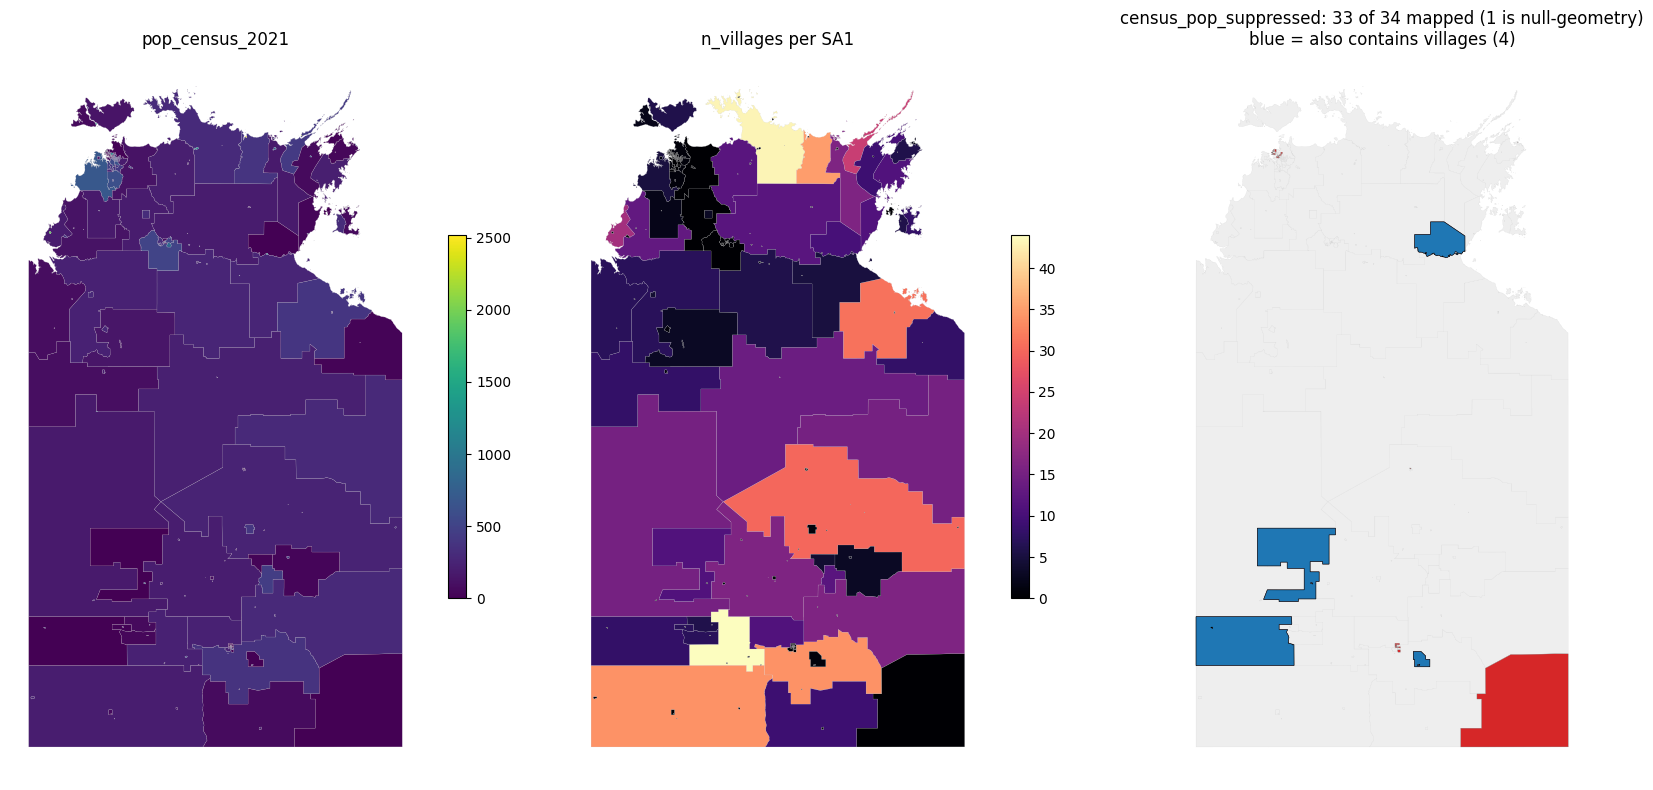

In [14]:
g = sa1_report_geojson_gdf

fig, axes = plt.subplots(1, 3, figsize=(17, 8))
g.plot(ax=axes[0], column="pop_census_2021", cmap="viridis", legend=True,
       legend_kwds={"shrink": 0.5}, edgecolor="0.8", linewidth=0.1)
axes[0].set_title("pop_census_2021"); axes[0].set_axis_off()

g.plot(ax=axes[1], column="n_villages", cmap="magma", legend=True,
       legend_kwds={"shrink": 0.5}, edgecolor="0.8", linewidth=0.1)
axes[1].set_title("n_villages per SA1"); axes[1].set_axis_off()

g.plot(ax=axes[2], color="#eeeeee", edgecolor="0.8", linewidth=0.1)
sup = g[g["census_pop_suppressed"]]
sup.plot(ax=axes[2], color="#d62728", edgecolor="0.5", linewidth=0.2)
sup_with_villages = sup[sup["n_villages"] > 0]
sup_with_villages.plot(ax=axes[2], color="#1f77b4", edgecolor="k", linewidth=0.4)
axes[2].set_title(f"census_pop_suppressed: {len(sup)} of 34 mapped (1 is null-geometry)\n"
                  f"blue = also contains villages ({len(sup_with_villages)})")
axes[2].set_axis_off()
fig.tight_layout()
eda_figures["02_sa1_report_choropleths"] = fig

In [15]:
# Second-to-last cell: summary print.
print("02_sa1_report — summary")
print("-" * 62)
print(f"rows out : {len(sa1_report_df)} SA1s (sa1_report.csv)  |  GeoJSON: {len(sa1_report_geojson_gdf)} polygons")
print(f"dropped  : 0 from the table; {len(null_geom)} null-geometry rows excluded from the GeoJSON only")
print(f"census_pop_suppressed : {int(sa1_report_df['census_pop_suppressed'].sum())} SA1s "
      f"({int((sa1_report_df['census_pop_suppressed'] & (sa1_report_df['n_villages'] > 0)).sum())} of them contain villages) "
      f"-> also written to area_with_population_lessthan_5.csv")
print(f"G02 0 -> NaN : income {int(sa1_report_df['median_hh_income_weekly'].isna().sum())}, "
      f"household size {int(sa1_report_df['avg_household_size'].isna().sum())}")
print(f"villages rolled up : {int(sa1_report_df['n_villages'].sum())} (== nb 01's 792)")
print(f"pop_census_2021 total across NT SA1s : {int(sa1_report_df['pop_census_2021'].sum()):,}")
print("asserts passed: 1:1 on every merge, 649 rows, key unique, columns fixed, roll-up total == 792, 645 polygons")

02_sa1_report — summary
--------------------------------------------------------------
rows out : 649 SA1s (sa1_report.csv)  |  GeoJSON: 645 polygons
dropped  : 0 from the table; 4 null-geometry rows excluded from the GeoJSON only
census_pop_suppressed : 34 SA1s (4 of them contain villages) -> also written to area_with_population_lessthan_5.csv
G02 0 -> NaN : income 34, household size 33
villages rolled up : 792 (== nb 01's 792)
pop_census_2021 total across NT SA1s : 232,565
asserts passed: 1:1 on every merge, 649 rows, key unique, columns fixed, roll-up total == 792, 645 polygons


In [16]:
# Last cell: every file write.
csv_path      = OUT_DIR / "sa1_report.csv"
geojson_path  = OUT_DIR / "sa1_report.geojson"
suppressed_path = OUT_DIR / "area_with_population_lessthan_5.csv"

sa1_report_df.to_csv(csv_path, index=False)
sa1_report_geojson_gdf.to_file(geojson_path, driver="GeoJSON")
sa1_report_df[sa1_report_df["census_pop_suppressed"]].to_csv(suppressed_path, index=False)

for name, fig in eda_figures.items():
    fig.savefig(EDA_PLOT_DIR / f"{name}.png", dpi=120, bbox_inches="tight")

print("wrote:")
print(" ", csv_path, f"({len(sa1_report_df)} rows)")
print(" ", geojson_path, f"({len(sa1_report_geojson_gdf)} features)")
print(" ", suppressed_path, f"({int(sa1_report_df['census_pop_suppressed'].sum())} rows)")
for name in eda_figures:
    print("  docs/eda/" + name + ".png")

wrote:
  data\new_processed\sa1_report.csv (649 rows)
  data\new_processed\sa1_report.geojson (645 features)
  data\new_processed\area_with_population_lessthan_5.csv (34 rows)
  docs/eda/02_sa1_report_choropleths.png
